In [1]:
# Name: Chhayank Sharma
# Registration no.: 60
# Demo given to introduce seaborn library for DAV lab

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)

In [4]:
mtc = pd.DataFrame(pd.read_csv('mtcars.csv'))
mtc

,manufacturer,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


In [5]:
print(mtc.shape)
print(mtc.info())
print(mtc.describe())

(32, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   manufacturer  32 non-null     object 
 1   mpg           32 non-null     float64
 2   cyl           32 non-null     int64  
 3   disp          32 non-null     float64
 4   hp            32 non-null     int64  
 5   drat          32 non-null     float64
 6   wt            32 non-null     float64
 7   qsec          32 non-null     float64
 8   vs            32 non-null     int64  
 9   am            32 non-null     int64  
 10  gear          32 non-null     int64  
 11  carb          32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB
None
             mpg        cyl        disp          hp       drat         wt       qsec         vs         am       gear     carb
count  32.000000  32.000000   32.000000   32.000000  32.000000  32.000000  32.000000  32.000

In [6]:
mtc.nunique()

manufacturer    32
mpg             25
cyl              3
disp            27
hp              22
drat            22
wt              29
qsec            30
vs               2
am               2
gear             3
carb             6
dtype: int64

In [7]:
mtc.groupby("cyl")["mpg"].mean()

cyl
4    26.663636
6    19.742857
8    15.100000
Name: mpg, dtype: float64

<AxesSubplot:>

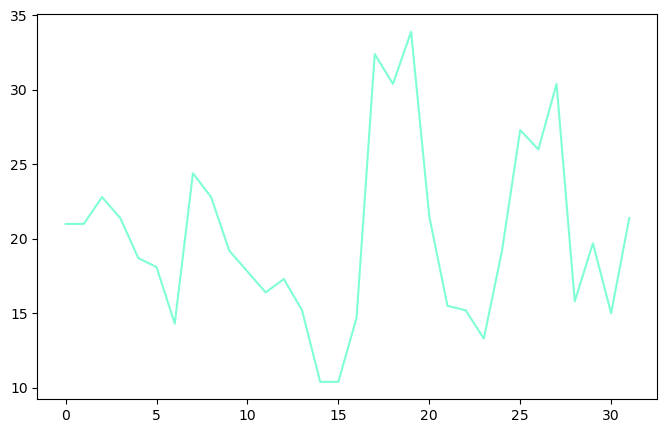

In [8]:
mtc["mpg"].plot(color = "aquamarine", use_index=False)

<AxesSubplot:>

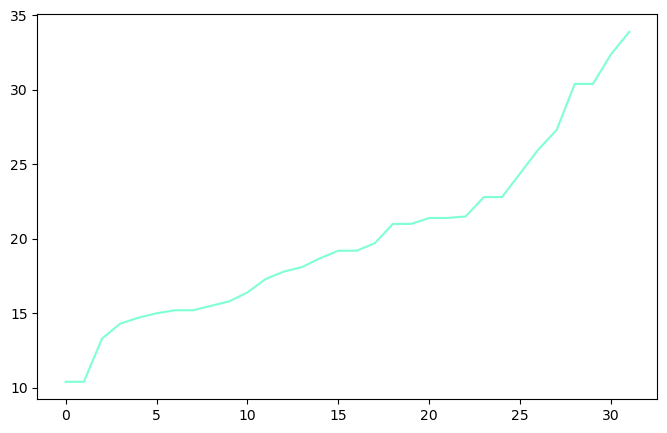

In [9]:
mtc["mpg"].sort_values().reset_index(drop=True).plot(color = "aquamarine")

In [10]:
plt.style.use("ggplot")

<AxesSubplot:xlabel='wt', ylabel='mpg'>

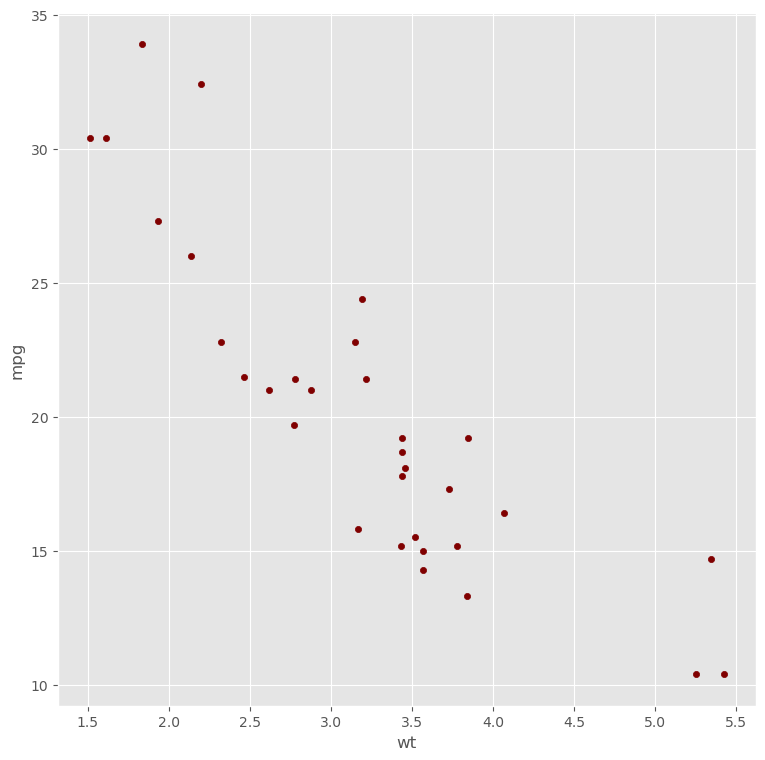

In [14]:
mtc.plot(kind = "scatter", x = "wt", y = "mpg", figsize = (9, 9), color = "maroon")

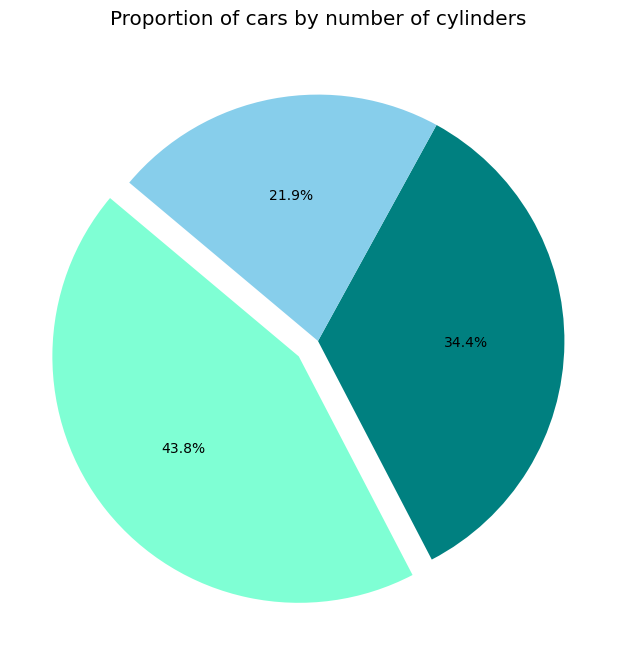

In [24]:
plt.figure(figsize = (8, 8))
plt.pie(mtc["cyl"].value_counts(),
        autopct = "%1.1f%%",
        colors = ["aquamarine", "teal", "skyblue"],
        startangle = 140,
        explode = [0.1, 0, 0]
       )
plt.title("Proportion of cars by number of cylinders")
plt.show()

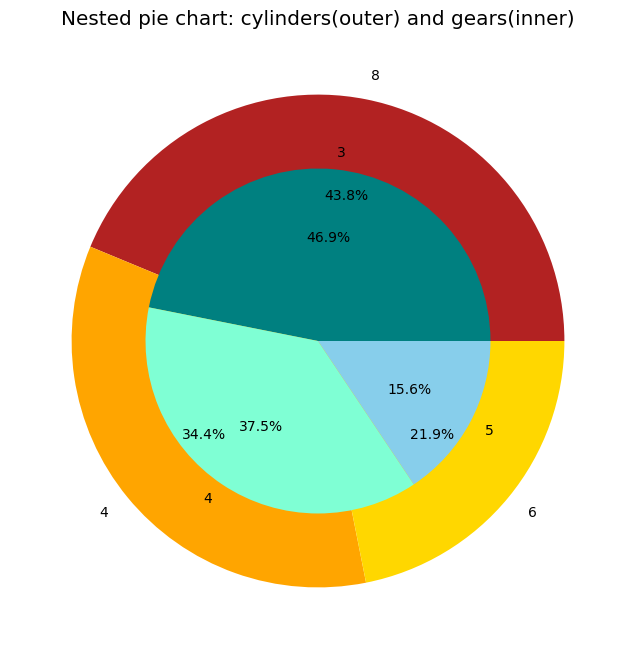

In [36]:
outer_labels = mtc["cyl"].value_counts().index
outer_sizes = mtc["cyl"].value_counts().values

inner_labels = mtc["gear"].value_counts().index
inner_sizes = mtc["gear"].value_counts().values

fig, ax = plt.subplots(figsize = (8, 8))
ax.pie(outer_sizes, labels = outer_labels, radius = 1, autopct = "%1.1f%%", colors = ["firebrick", "orange", "gold"])
ax.pie(inner_sizes, labels = inner_labels, radius = 0.7, autopct = "%1.1f%%", colors = ["teal", "aquamarine", "skyblue"])

ax.set(aspect = "equal")
plt.title("Nested pie chart: cylinders(outer) and gears(inner)")
plt.show()

In [37]:
mtc["cyl"].value_counts()

8    14
4    11
6     7
Name: cyl, dtype: int64

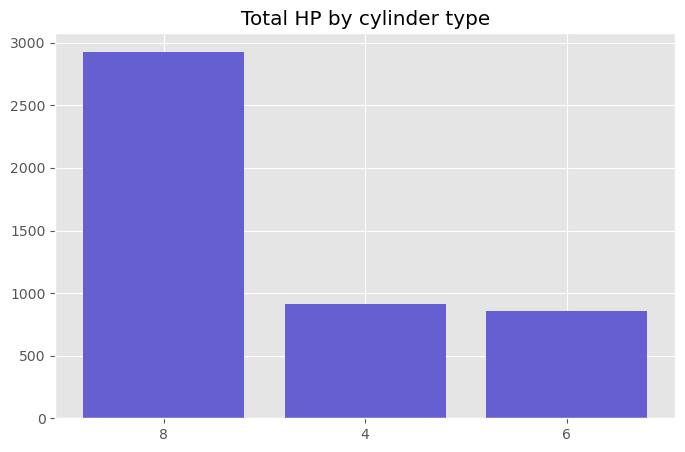

In [44]:
top_power = mtc.groupby("cyl")["hp"].sum().sort_values(ascending=False)
plt.bar(top_power.index.astype(str), top_power.values, color = "xkcd:dark periwinkle")
plt.title("Total HP by cylinder type")
plt.show()

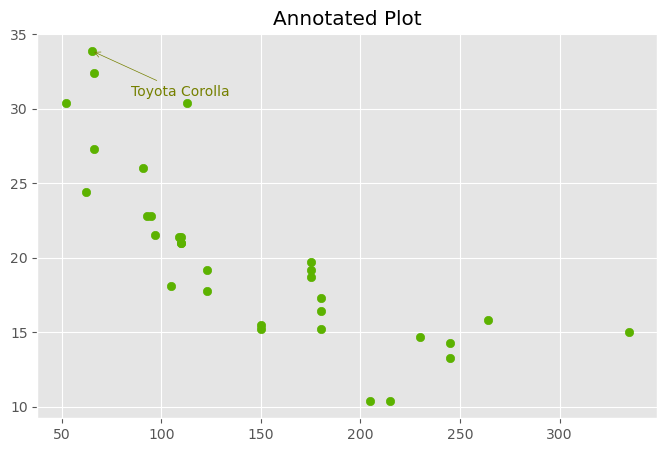

In [59]:
best = mtc.loc[mtc["mpg"].idxmax()]
plt.scatter(mtc["hp"], mtc["mpg"], color="xkcd:kermit green")
plt.annotate(best["manufacturer"],
            (best["hp"], best["mpg"]),
            xytext=(best["hp"]+20, best["mpg"]-3),
            arrowprops=dict(arrowstyle="->", color="xkcd:shit green"),
            color="xkcd:shit green"
           )
plt.title("Annotated Plot")
plt.show()